<a href="https://colab.research.google.com/github/eddie-root/Detec-o_de_Anomalias_em_Transacoes_em_Python/blob/main/creditcard_fraud_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Importar dados

In [ ]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


 Carregamos o dataset de transações de cartão de crédito. df.head() mostra as primeiras linhas.

 No contexto de fraude:

 aqui você está trazendo o histórico de transações. Cada linha é uma operação de cartão de crédito, e a coluna Class indica se foi fraude (1) ou não (0). É como abrir o “livro-caixa” para começar a investigar.

2. Distribuição da variável alvo

In [ ]:
df["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


Mostra a proporção de fraudes (1) e não fraudes (0). Isso revela o desbalanceamento.

No contexto de fraude:

mostra que fraudes são raras (menos de 1%). Isso explica por que modelos simples podem errar: se sempre disser “não fraude”, já acerta 99% — mas deixa passar o que realmente importa.

3. Transformação logarítmica

In [ ]:
import numpy as np

df["Amount_log"] = np.log1p(df["Amount"])

print(df['Amount_log'])


0         5.014760
1         1.305626
2         5.939276
3         4.824306
4         4.262539
            ...   
284802    0.570980
284803    3.249987
284804    4.232366
284805    2.397895
284806    5.384495
Name: Amount_log, Length: 284807, dtype: float64


 log1p aplica log(1+x) para reduzir a escala dos valores monetários.

 No contexto de fraude:

 valores de transações variam muito (de centavos a milhares). Aplicar log ajuda a reduzir essa diferença, permitindo que o modelo veja padrões mais claros entre valores pequenos e grandes.

4. Padronização

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])


In [ ]:
print(df['Amount_scaled'])

0         0.244964
1        -0.342475
2         1.160686
3         0.140534
4        -0.073403
            ...   
284802   -0.350151
284803   -0.254117
284804   -0.081839
284805   -0.313249
284806    0.514355
Name: Amount_scaled, Length: 284807, dtype: float64


Normaliza os valores para média 0 e desvio padrão 1.

No contexto de fraude:

normalizar garante que o modelo não dê peso exagerado a variáveis com números grandes (como “Amount”), equilibrando todas as features na análise.

5. Divisão treino/teste

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

print(df['Class'])


0         0
1         0
2         0
3         0
4         0
         ..
284802    0
284803    0
284804    0
284805    0
284806    0
Name: Class, Length: 284807, dtype: int64


Divide os dados em treino (70%) e teste (30%), mantendo proporção de classes.

No contexto de fraude:

separar treino e teste é como treinar um detetive com parte dos casos e depois avaliar se ele consegue identificar fraudes em casos novos que nunca viu.

6. Regressão logística

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)



In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled, y_train)


Treina um modelo simples de classificação binária.

No contexto de fraude:

a regressão logística calcula a probabilidade de uma transação ser fraude. Se passar de 0.5, marca como fraude. É como um alarme que dispara quando a chance é alta.

7. Relatório de métricas

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.66      0.73       148

    accuracy                           1.00     85443
   macro avg       0.92      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



Mostra precisão, recall e F1-score.

No contexto de fraude:

mostra se o modelo está conseguindo identificar fraudes sem acusar demais transações normais. O recall é crucial: perder uma fraude é pior do que acusar uma transação legítima.

8. Curva ROC

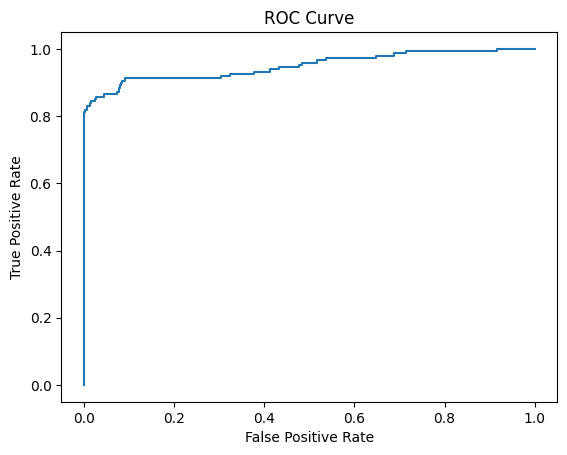

AUC: 0.9488893078552496


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_probs = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))


Avalia desempenho do modelo em diferentes limiares.

No contexto de fraude:

mostra o trade-off entre capturar fraudes (true positives) e gerar alarmes falsos (false positives). Um bom modelo fica mais próximo do canto superior esquerdo.

9. Curva Precision-Recall

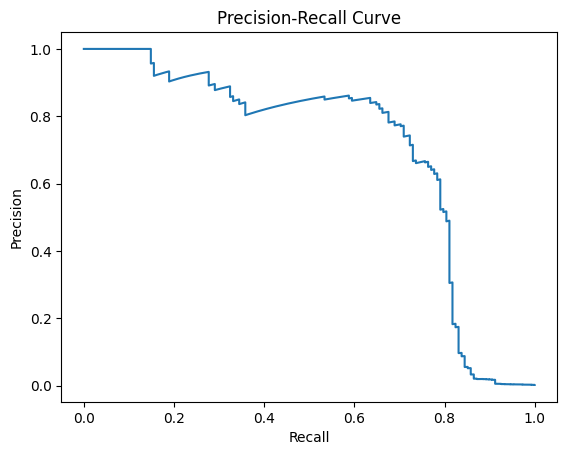

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()



 Útil em datasets desbalanceados.

 No contexto de fraude:

 útil porque fraudes são raras. Mostra se o modelo consegue manter precisão alta mesmo quando tenta capturar mais fraudes.

10. Balanceamento – Undersampling

In [ ]:
# Balanceamento de dados
# Undersampling
fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])


Reduz a classe majoritária para equilibrar.

No contexto de fraude:

reduz o número de transações normais para equilibrar com as fraudes. É como treinar o detetive com a mesma quantidade de casos bons e ruins.

11. Balanceamento – Oversampling (SMOTE)

In [ ]:
# Oversampling

from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_res, y_res = smote.fit_resample(X, y)



Gera exemplos sintéticos da classe minoritária.

No contexto de fraude:

cria exemplos sintéticos de fraude para aumentar a representatividade. É como simular novos casos de fraude para treinar melhor o modelo.

12. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))




              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



Modelo mais robusto que regressão logística.

No contexto de fraude:

usa várias árvores de decisão para votar se uma transação é fraude. Isso reduz erros e melhora a robustez.

13. Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)



Automatiza pré-processamento + modelo.

No contexto de fraude:

automatiza o processo: sempre que entrar uma nova transação, ela será normalizada e classificada sem precisar repetir manualmente os passos.

14. Threshold customizado

In [ ]:
threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.79      0.68      0.73       148

    accuracy                           1.00     85443
   macro avg       0.90      0.84      0.86     85443
weighted avg       1.00      1.00      1.00     85443



Ajusta o limiar de decisão para aumentar recall.

No contexto de fraude:

mudar o limiar (ex: 0.3) significa ser mais “paranoico”: o modelo acusa fraude mais facilmente, aumentando recall mas também falsos alarmes.

15. XGBoost

In [ ]:
# Modelo Avançado xgboost
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10,
    eval_metric="logloss",
    random_state=42
)


xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))




              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



Modelo avançado, ótimo para dados desbalanceados.

No contexto de fraude:

modelo avançado que lida bem com desbalanceamento. É como um detetive mais experiente, que aprende padrões complexos.

16. Importância das variáveis

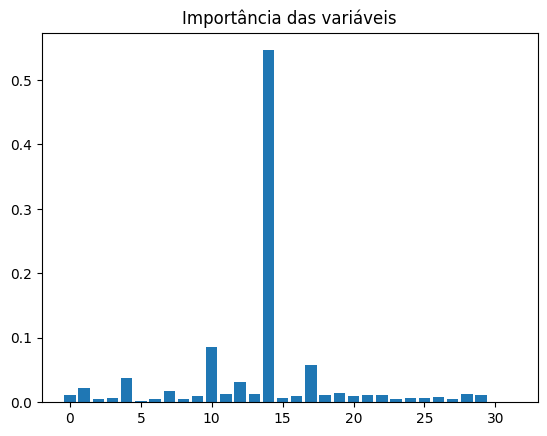

In [ ]:

import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")
plt.show()



Mostra quais features mais influenciam o modelo.

No contexto de fraude:

mostra quais características mais influenciam na decisão. Por exemplo, tempo da transação ou valor podem ser fortes indicadores.

17. Grid Search

In [ ]:

from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3,5],
    "n_estimators": [50,100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_


print("Melhor modelo : ", grid.best_params_)


Melhor modelo :  {'max_depth': 5, 'n_estimators': 100}


Busca hiperparâmetros ótimos para maximizar recall.

No contexto de fraude:

busca a melhor combinação de parâmetros para maximizar recall. É como treinar o detetive em diferentes estilos e escolher o que mais captura fraudes.